In [1]:
# Install the notebook's Python dependencies (safe to re-run; needed on a fresh kernel / Colab).
%pip install -q "psycopg[binary]" numpy pandas matplotlib pyproj pillow

Note: you may need to restart the kernel to use updated packages.


# Tcbuffer vs tgeompoint — noise-footprint cost & expressiveness on AIS

This notebook measures, on **one day of AIS** (Automatic Identification System) data from the
[Danish Maritime Authority](http://aisdata.ais.dk/), what it costs and what it buys to model a
vessel not as a moving **point** but as a moving **disk** — a *tcbuffer*, the centerline plus a
time-varying radius that captures positional noise / vessel extent.

It is a sibling of the MobilityAPI [`tutorial/tutorial.ipynb`](https://github.com/MobilityDB/MobilityAPI/blob/master/tutorial/tutorial.ipynb)
and [`tutorial-stream/tutorial.ipynb`](https://github.com/MobilityDB/MobilityAPI/blob/master/tutorial-stream/tutorial.ipynb)
and of the BerlinMOD [`CrossPlatform_timings`](../CrossPlatform_timings_2026-05-12.md) catalog: same
AIS day, same map idiom. The difference is what we measure — those are tutorials / cross-platform
latency; this pairs two **models of the same trip** on one engine (MobilityDB) and times the same
operator on each:

- **`Trip`** — a `tgeompoint` centerline (the vessel as a moving point).
- **`Noise`** — a `tcbuffer` (the same centerline carrying a time-varying noise radius: the vessel as a moving disk).

Every operator runs as the natural SQL expression of a fixed English intent — no `&&` pre-filters,
no tolerance knobs, no index hints — so the numbers are the cost of the operator itself.

## What this benchmark measures

For each spatial/temporal operator MobilityDB exposes, we run the **same query twice** over an
`N`-vessel × `M`-object cross join — once with the `Trip` (tgeompoint) argument, once with the
`Noise` (tcbuffer) argument — and record the wall-clock time and the result count. Three families:

| Section | Cross join | Question |
|---|---|---|
| **A — Trip × geometry** | vessels × protected areas | restrict / distance / topological relations against a fixed polygon |
| **B — Trip × cbuffer**  | vessels × buffered areas | the same, against a circular-buffer object |
| **C — Trip × Trip**     | vessels × vessels        | vessel-to-vessel encounter / distance (the N×N self-join) |

The headline is the **noise-exposure gap**: how many area reaches the disk model finds that the
centerline misses, and what that costs.

## Setup

In [2]:
%matplotlib inline
import os, math, io, time, json, urllib.request
import psycopg
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from pyproj import Transformer
from PIL import Image

# --- Connection (override via PG* env vars) -----------------------------------
PGHOST = os.environ.get("PGHOST", "/tmp")
PGPORT = os.environ.get("PGPORT", "5432")
PGDATABASE = os.environ.get("PGDATABASE", "tcbuffer_bench")
PGUSER = os.environ.get("PGUSER", os.environ.get("USER", "postgres"))
DSN = f"host={PGHOST} port={PGPORT} dbname={PGDATABASE} user={PGUSER}"

# --- Benchmark scale ----------------------------------------------------------
# N is the size of each side of the cross joins (vessels, and areas in A/B).
# The full day yields a few thousand vessels; the N×N geometric operators in
# Section C grow as N², so the default keeps a full pass within ~20-30 min.
# Raise N on your own machine for a larger run; lower it for a quick look.
N = int(os.environ.get("TCBUFFER_N", "100"))

# Per-statement safety cap (seconds) for the interactive tier.
STMT_TIMEOUT = int(os.environ.get("TCBUFFER_STMT_TIMEOUT", "120"))

# The temporal-output spatial relations (tIntersects / tDwithin / tContains /
# tCovers / … — they materialize a temporal boolean over the whole trajectory ×
# the full multipolygon) are the cost frontier: against high-vertex areas a
# single Noise evaluation runs for minutes and does not yield to cancellation
# (MEOS evaluates them without an interrupt check). They are OFF by default so a
# run stays bounded; set TCBUFFER_RUN_FRONTIER=1 to include them (can run hours).
RUN_FRONTIER = os.environ.get("TCBUFFER_RUN_FRONTIER", "0") in ("1", "true", "True")

# Path to the benchmark query catalog (single source of truth for the SQL).
BENCH_SQL = os.environ.get("TCBUFFER_BENCH_SQL", "tcbuffer_benchmark.sql")
print(f"DSN = {DSN}\nN   = {N}\nstatement cap = {STMT_TIMEOUT}s")

DSN = host=/tmp port=5499 dbname=tcbuffer_bench user=esteban
N   = 50
statement cap = 120s


Two small helpers, the same ones the MobilityAPI tutorial uses — a self-contained XYZ-tile
basemap (so we need only `matplotlib` / `pyproj` / `Pillow`) and a geometry plotter — adapted here
to draw WKT returned by SQL (a `Trip` centerline as a line, a `Noise` footprint as a filled disk-swept polygon).

In [3]:
# --- OSM XYZ-tile basemap (fetch + stitch), reprojecting data to Web Mercator ---
_WORLD = 20037508.342789244
_CACHE = "/tmp/tcbuffer_tiles"; os.makedirs(_CACHE, exist_ok=True)
def _tile(z, x, y):
    p = f"{_CACHE}/{z}_{x}_{y}.png"
    if not os.path.exists(p):
        req = urllib.request.Request(f"https://tile.openstreetmap.org/{z}/{x}/{y}.png",
                                     headers={"User-Agent": "mobilitydb-tcbuffer-bench/1.0"})
        open(p, "wb").write(urllib.request.urlopen(req, timeout=25).read())
    return Image.open(p).convert("RGB")
def _m2t(x, y, z): n = 2**z; return (x+_WORLD)/(2*_WORLD)*n, (_WORLD-y)/(2*_WORLD)*n
def _t2m(tx, ty, z): n = 2**z; return tx/n*2*_WORLD-_WORLD, _WORLD-ty/n*2*_WORLD
def add_basemap(ax, xmin, ymin, xmax, ymax):
    span = max(xmax-xmin, ymax-ymin); z = 12
    for zz in range(3, 17):
        if span/(2*_WORLD/2**zz) >= 4: z = zz; break
    tx0, ty1 = _m2t(xmin, ymin, z); tx1, ty0 = _m2t(xmax, ymax, z)
    x0, x1 = math.floor(tx0), math.ceil(tx1); y0, y1 = math.floor(ty0), math.ceil(ty1)
    mos = Image.new("RGB", ((x1-x0)*256, (y1-y0)*256), (238, 238, 238))
    for xi in range(x0, x1):
        for yi in range(y0, y1):
            try: mos.paste(_tile(z, xi, yi), ((xi-x0)*256, (yi-y0)*256))
            except Exception: pass
    mx0, my1 = _t2m(x0, y0, z); mx1, my0 = _t2m(x1, y1, z)
    ax.imshow(mos, extent=[mx0, mx1, my0, my1], zorder=0)
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)

# data SRID is detected at runtime; build the transformer to Web Mercator once known
_transformer = {"srid": None, "fn": None}
def _to3857(srid):
    if _transformer["srid"] != srid:
        _transformer["srid"] = srid
        _transformer["fn"] = Transformer.from_crs(srid, 3857, always_xy=True)
    return _transformer["fn"]

def _rings_from_wkt(wkt):
    """Yield coordinate lists for LINESTRING / POLYGON / MULTI* WKT (degrees or metres)."""
    import re
    out = []
    for chunk in re.findall(r"\(([-0-9eE.,\s]+)\)", wkt):
        pts = []
        for pair in chunk.split(","):
            xy = pair.split()
            if len(xy) >= 2:
                pts.append((float(xy[0]), float(xy[1])))
        if len(pts) >= 2: out.append(pts)
    return out

def plot_geoms(groups, srid, title="", figsize=(9, 7)):
    """groups: list of (list_of_wkt, color, kind, alpha, label); kind in {'line','fill'}."""
    tr = _to3857(srid); fig, ax = plt.subplots(figsize=figsize); pts = []; drawn = []
    for wkts, color, kind, alpha, label in groups:
        polys = []
        for w in wkts:
            for ring in _rings_from_wkt(w):
                X, Y = tr.transform([p[0] for p in ring], [p[1] for p in ring])
                xy = list(zip(X, Y)); polys.append(xy); pts += xy
        drawn.append((polys, color, kind, alpha, label))
    if not pts: print("nothing to plot"); return
    a = np.array(pts); xmin, ymin, xmax, ymax = a[:,0].min(), a[:,1].min(), a[:,0].max(), a[:,1].max()
    dx = (xmax-xmin)*0.08 or 2000; dy = (ymax-ymin)*0.08 or 2000
    add_basemap(ax, xmin-dx, ymin-dy, xmax+dx, ymax+dy)
    for polys, color, kind, alpha, label in drawn:
        if kind == "fill":
            for xy in polys: ax.add_patch(mpatches.Polygon(xy, closed=True, facecolor=color, edgecolor=color, alpha=alpha, lw=0.8, zorder=3))
            ax.plot([], [], color=color, alpha=min(1, alpha+0.3), lw=6, label=label)
        else:
            ax.add_collection(LineCollection(polys, colors=color, linewidths=1.6, alpha=alpha, label=label, zorder=4))
    ax.set_axis_off(); ax.set_title(title); ax.legend(loc="lower right", frameon=True)
    plt.tight_layout(); plt.show()

## Preflight — is MobilityDB reachable, and on the pin?

In [4]:
conn = psycopg.connect(DSN, autocommit=True)
def q1(sql, args=None):
    with conn.cursor() as c: c.execute(sql, args); r = c.fetchone(); return r[0] if r else None
print("PostgreSQL :", q1("SHOW server_version"))
print("MobilityDB :", q1("SELECT mobilitydb_version()"))
print("PostGIS    :", q1("SELECT postgis_lib_version()"))
assert q1("SELECT 1 FROM pg_type WHERE typname = 'tcbuffer'"), "tcbuffer type missing — build with -DCBUFFER=ON"
print("tcbuffer   : present")

PostgreSQL : 17.8
MobilityDB : MobilityDB 1.4.0
PostGIS    : 3.6.3
tcbuffer   : present


## The dataset — one full day of AIS

`tcbuffer_load(SF:=1)` ingests one day of Danish AIS, reconstructs each vessel's voyage, and stores
two columns side by side in `VesselTrip`:

- **`Trip`** `tgeompoint` — the centerline;
- **`Noise`** `tcbuffer` — the same centerline carrying a time-varying noise radius.

Protected-area polygons (`NaturalAreas`) are the fixed objects in Sections A/B. We size the run with
`N` by taking the first `N` vessels / areas into views the catalog queries against.

In [5]:
vessels = q1("SELECT count(*) FROM VesselTrip")
areas   = q1("SELECT count(*) FROM NaturalAreas")
srid    = q1("SELECT ST_SRID(trajectory(Trip)) FROM VesselTrip WHERE Trip IS NOT NULL LIMIT 1")
extent  = q1("SELECT tstzspan(timeSpan(Trip)) FROM VesselTrip WHERE Trip IS NOT NULL ORDER BY TripId LIMIT 1")
print(f"vessels in the day : {vessels}")
print(f"protected areas    : {areas}")
print(f"data SRID          : {srid}")
print(f"using N            : {N}  (each side of the cross joins)")

# Size the run: the catalog references VesselTrip100 / NaturalAreas100 / NaturalAreasCb100 by name;
# we (re)define them as the first N rows, so the SQL is unchanged and N is the only knob.
with conn.cursor() as c:
    # the loader may leave these as views or tables; drop each by its actual kind
    c.execute("""DO $$ DECLARE r record; BEGIN
      FOR r IN SELECT c.relname, c.relkind FROM pg_class c JOIN pg_namespace n ON n.oid=c.relnamespace
               WHERE c.relname IN ('vesseltrip100','naturalareas100','naturalareascb100') AND n.nspname='public' LOOP
        IF r.relkind='v' THEN EXECUTE 'DROP VIEW IF EXISTS '||quote_ident(r.relname)||' CASCADE';
        ELSE EXECUTE 'DROP TABLE IF EXISTS '||quote_ident(r.relname)||' CASCADE'; END IF;
      END LOOP; END $$;""")
    c.execute(f"CREATE VIEW VesselTrip100 AS SELECT * FROM VesselTrip ORDER BY TripId LIMIT {N}")
    c.execute(f"CREATE VIEW NaturalAreas100 AS SELECT * FROM NaturalAreas ORDER BY Id LIMIT {N}")
    # cbuffer object for Section B: the canonical bounding circle of each area, cbuffer(geom)
    c.execute(f"CREATE VIEW NaturalAreasCb100 AS SELECT Id, cbuffer(geom) AS cb FROM NaturalAreas ORDER BY Id LIMIT {N}")
print("views VesselTrip100 / NaturalAreas100 / NaturalAreasCb100 created")

# The protected areas are high-vertex multipolygons — the genuine cost driver for the
# geometric operators (intersection / distance against the swept Noise footprint). Kept
# at full resolution (no simplification), so the numbers are the true operator cost.
with conn.cursor() as c:
    c.execute(f"""SELECT count(*), round(avg(np))::int,
                  percentile_cont(0.5)  WITHIN GROUP (ORDER BY np)::int AS median,
                  percentile_cont(0.95) WITHIN GROUP (ORDER BY np)::int AS p95,
                  max(np), sum(np), max(ng)
                  FROM (SELECT ST_NPoints(geom) np, ST_NumGeometries(geom) ng
                        FROM NaturalAreas ORDER BY Id LIMIT {N}) s""")
    cnt, mean, med, p95, mx, tot, mxg = c.fetchone()
print(f"area polygons     : {cnt}")
print(f"vertices per area : mean {mean:,}  median {med:,}  p95 {p95:,}  max {mx:,}")
print(f"sub-polygons/area : up to {mxg};  total vertices across the {cnt} areas: {tot:,}")
area_complexity = dict(count=cnt, mean=mean, median=med, p95=p95, max=mx, total=tot, max_subpolys=mxg)

vessels in the day : 2833
protected areas    : 283
data SRID          : 25832
using N            : 50  (each side of the cross joins)
views VesselTrip100 / NaturalAreas100 / NaturalAreasCb100 created
area polygons     : 50
vertices per area : mean 262  median 30  p95 1,401  max 2,175
sub-polygons/area : up to 9;  total vertices across the 50 areas: 13,103


### A vessel as a point and as a disk

The visual hook, in the same map style as the MobilityAPI tutorial: a few vessels' `Trip`
centerlines (lines) overlaid with their `Noise` footprints — `traversedArea(Noise)`, the polygon the
moving disk sweeps. The footprint is what turns a centerline into a noise-exposure assessment.

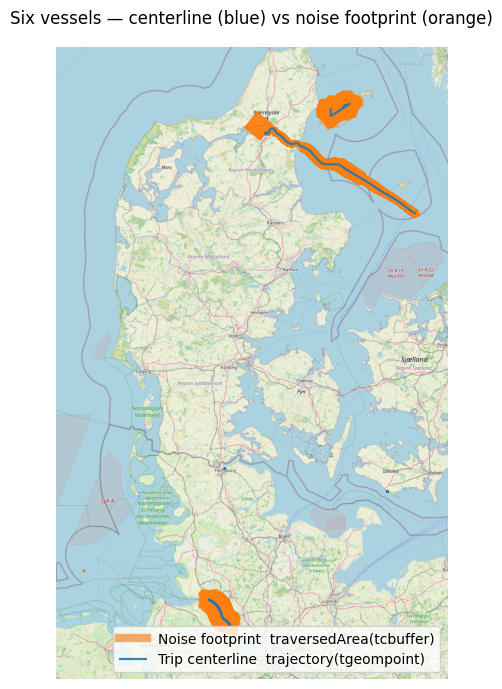

In [6]:
with conn.cursor() as c:
    c.execute("""SELECT ST_AsText(traversedArea(Noise)), ST_AsText(trajectory(Trip))
                 FROM VesselTrip ORDER BY TripId LIMIT 6""")
    rows = c.fetchall()
foot = [r[0] for r in rows if r[0]]
line = [r[1] for r in rows if r[1]]
plot_geoms([(foot, "#ff7f0e", "fill", 0.35, "Noise footprint  traversedArea(tcbuffer)"),
            (line, "#1f77b4", "line", 0.9,  "Trip centerline  trajectory(tgeompoint)")],
           srid, title="Six vessels — centerline (blue) vs noise footprint (orange)")

## Invariants held fixed

- **Same kernel.** One MobilityDB pin builds both columns; `Trip` and `Noise` differ only in the model.
- **Natural SQL.** Each query is the plain expression of its English intent — no `&&` bbox pre-filter,
  no tolerance, no `SET` knobs, no index hints. The time is the operator's own cost.
- **Same cross join.** Trip and Noise are timed over identical `N`-row view pairs.
- **Exact operators.** No approximation or sampling; an unimplemented pair raises rather than guesses.

## The query catalog

The operators come straight from [`tcbuffer_benchmark.sql`](tcbuffer_benchmark.sql) — the single
source of truth — parsed into (section, operator, model, sql) tuples. Each is run once and timed.

In [7]:
import re
def load_catalog(path):
    """Parse the benchmark .sql into [(section, sub, operator, model, sql)].
    Comment-aware: strips /* */ and -- so a ';' inside a comment is not a
    statement, while still reading section/sub labels out of the comments.
    model is Trip / Noise (paired), or 'showcase' when a statement names both."""
    text = open(path).read()
    n = len(text); i = 0; buf = []; section = sub = ""; items = []
    def emit(stmt):
        s = stmt.strip()
        if not s.upper().startswith("SELECT") or "FROM" not in s.upper(): return
        low = s.lower()
        has_t, has_n = bool(re.search(r"\btrip\b", low)), bool(re.search(r"\bnoise\b", low))
        model = "Trip" if has_t and not has_n else "Noise" if has_n and not has_t else "showcase"
        if "mindistance" in low and "group by" in low:
            op = "minDistance(·,·) set×set"
        elif "WHERE" in s.upper():
            w = s[s.upper().rfind("WHERE")+5:]
            op = re.sub(r"\bt[12]\.", "", w)
            op = re.sub(r"\bNoise\b|\bTrip\b", "·", op)
            op = re.sub(r"\s+", " ", op).strip().rstrip(";")
        else:
            op = re.sub(r"\s+", " ", s)[:48]
        items.append((section, sub, op, model, s))
    while i < n:
        if text[i:i+2] == "/*":
            j = text.find("*/", i+2); j = j+2 if j >= 0 else n
            comment = text[i:j]
            m = re.search(r"Section\s+([A-D])\s*-\s*([^\n*]+)", comment)
            if m: section = f"{m.group(1)} - {m.group(2).strip()}"
            m = re.search(r"\b([A-D]\d)\s*-\s*([^\n*]+)", comment)
            if m: sub = f"{m.group(1)} {m.group(2).strip()}"
            i = j; continue
        if text[i:i+2] == "--":
            j = text.find("\n", i); i = j if j >= 0 else n; continue
        if text[i] == ";":
            emit("".join(buf)); buf = []; i += 1; continue
        buf.append(text[i]); i += 1
    return items

def is_frontier(sub, op):
    return ("temporal-output" in sub.lower()) or bool(
        re.match(r"\s*t(intersects|dwithin|contains|covers|disjoint|touches|equals)\b", op, re.I))

CATALOG = load_catalog(BENCH_SQL)
frontier = [c for c in CATALOG if is_frontier(c[1], c[2])]
if not RUN_FRONTIER:
    CATALOG = [c for c in CATALOG if not is_frontier(c[1], c[2])]
print(f"{len(CATALOG)} queries to run across sections {sorted({c[0][0] for c in CATALOG})}"
      f"  ·  {len(frontier)} frontier operators {'INCLUDED' if RUN_FRONTIER else 'held back (set TCBUFFER_RUN_FRONTIER=1)'}")

results = []   # (section, sub, operator, model, seconds, count, censored, error)
def run_timed(section, sub, op, model, sql):
    """Run one query with a per-statement safety cap. Records:
    - a real time + count when it completes;
    - censored (count=None) when it exceeds STMT_TIMEOUT — the cost frontier;
    - an error string (seconds=None) when the operator is not implemented for
      this argument pairing (a gap, reported as such, never an approximation)."""
    t0 = time.perf_counter()
    try:
        with conn.cursor() as c:
            c.execute(f"SET statement_timeout='{STMT_TIMEOUT}s'")
            c.execute(sql); cnt = c.fetchone()[0]
        dt = time.perf_counter() - t0
        results.append((section, sub, op, model, dt, cnt, False, None)); return dt, cnt, False, None
    except psycopg.errors.QueryCanceled:
        conn.rollback(); dt = time.perf_counter() - t0
        results.append((section, sub, op, model, dt, None, True, None)); return dt, None, True, None
    except psycopg.Error as e:
        conn.rollback(); msg = str(e).splitlines()[0][:70]
        results.append((section, sub, op, model, None, None, False, msg)); return None, None, False, msg

89 queries to run across sections ['A', 'B', 'C', 'D']  ·  23 frontier operators held back (set TCBUFFER_RUN_FRONTIER=1)


## Running the catalog

Each operator is timed on both models. The **restriction**, **distance / nearest-approach** and
**ever/always** families run in the interactive tier — including the Section C N×N vessel self-join,
the part the set-to-set distance optimizations target. The **temporal-output spatial relations**
(`tIntersects` / `tDwithin` / `tContains` / …) are held back as a frontier tier (see the parameters
cell): against the high-vertex multipolygons a single Noise evaluation runs for minutes and cannot be
cancelled, so they are not part of the default bounded run.

In [8]:
for i, (section, sub, op, model, sql) in enumerate(CATALOG, 1):
    dt, cnt, cens, err = run_timed(section, sub, op, model, sql)
    if err:    tag, ts = f"not implemented ({err})", "    n/a "
    elif cens: tag, ts = f"≥{STMT_TIMEOUT}s (censored)", f"{dt:8.2f}s"
    else:      tag, ts = f"count={cnt}", f"{dt:8.2f}s"
    print(f"[{i:3}/{len(CATALOG)}] {section[:1]} {sub:30.30} {model:5} {ts}  {tag}")
print("\nDONE — all operators timed.")

[  1/89] A A1 Restriction by geometry / s Noise     0.93s  count=12


[  2/89] A A1 Restriction by geometry / s Trip      0.75s  count=2500


[  3/89] A A1 Restriction by geometry / s Noise     1.37s  count=2500


[  4/89] A A1 Restriction by geometry / s Trip      0.67s  count=22


[  5/89] A A1 Restriction by geometry / s Noise     1.03s  count=22


...

[ 85/89] C C5 Aggregated set x set minimu Trip      9.73s  count=50


[ 86/89] C C5 Aggregated set x set minimu Noise    12.31s  count=50


[ 87/89] D D1 Protected areas reached by  Trip      1.37s  count=12


[ 88/89] D D2 Protected areas reached by  Noise    32.34s  count=52


[ 89/89] D D3 Gap: areas reached by noise showcase    32.23s  count=40

DONE — all operators timed.


## Results — execution time (s, lower is better)

The paired Trip vs Noise time per operator. The blue/orange split is the price of the disk model.

In [9]:
df = pd.DataFrame(results, columns=["section","sub","operator","model","seconds","count","censored","error"])
ncens = int(df["censored"].sum()); nerr = int(df["error"].notna().sum())
print(f"{len(df)} operators · {ncens} censored (≥ {STMT_TIMEOUT}s) · {nerr} not implemented for this pairing")
pivot = (df.pivot_table(index=["section","sub","operator"], columns="model",
                        values="seconds", aggfunc="first")
           .reset_index())
for c in ("Trip","Noise"):
    if c in pivot: pivot[c] = pivot[c].round(3)
if "Noise" in pivot and "Trip" in pivot:
    pivot["ratio"] = (pivot["Noise"] / pivot["Trip"]).round(1)
pd.set_option("display.max_rows", None, "display.width", 160)
display(pivot)

89 operators · 0 censored (≥ 120s) · 2 not implemented for this pairing


model,section,sub,operator,Noise,Trip,showcase,ratio
0,A - Trip x geometry: tgeompoint vs tcbuffer,A1 Restriction by geometry / stbox,"atGeometry(·, geom) IS NOT NULL",0.927,NaN,NaN,NaN
1,A - Trip x geometry: tgeompoint vs tcbuffer,A1 Restriction by geometry / stbox,"atStbox(·, stbox(geom)) IS NOT NULL",1.026,0.666,NaN,1.5
2,A - Trip x geometry: tgeompoint vs tcbuffer,A1 Restriction by geometry / stbox,"minusGeometry(·, geom) IS NOT NULL",1.374,0.749,NaN,1.8
3,A - Trip x geometry: tgeompoint vs tcbuffer,A1 Restriction by geometry / stbox,"minusStbox(·, stbox(geom)) IS NOT NULL",1.276,0.711,NaN,1.8
4,A - Trip x geometry: tgeompoint vs tcbuffer,A2 Distance / nearest approach,ST_Centroid(geom) <-> · IS NOT NULL,5.844,4.403,NaN,1.3
5,A - Trip x geometry: tgeompoint vs tcbuffer,A2 Distance / nearest approach,geom |=| · IS NOT NULL,10.727,14.828,NaN,0.7
6,A - Trip x geometry: tgeompoint vs tcbuffer,A2 Distance / nearest approach,"nearestApproachInstant(geom, ·) IS NOT NULL",67.047,61.034,NaN,1.1
7,A - Trip x geometry: tgeompoint vs tcbuffer,A2 Distance / nearest approach,"shortestLine(geom, ·) IS NOT NULL",29.860,18.906,NaN,1.6
8,A - Trip x geometry: tgeompoint vs tcbuffer,A3 Existential / always spatial relations,"aContains(geom, ·)",0.757,1.766,NaN,0.4
9,A - Trip x geometry: tgeompoint vs tcbuffer,A3 Existential / always spatial relations,"aCovers(geom, ·)",0.751,NaN,NaN,NaN


### Side-by-side grouped chart (Trip vs Noise, log scale, lower is better)

Same numbers as the table, log-scaled so the single-second restriction queries are not crushed by the
heavier distance / footprint operators. Blue = `tgeompoint` centerline; orange = `tcbuffer` noise model.

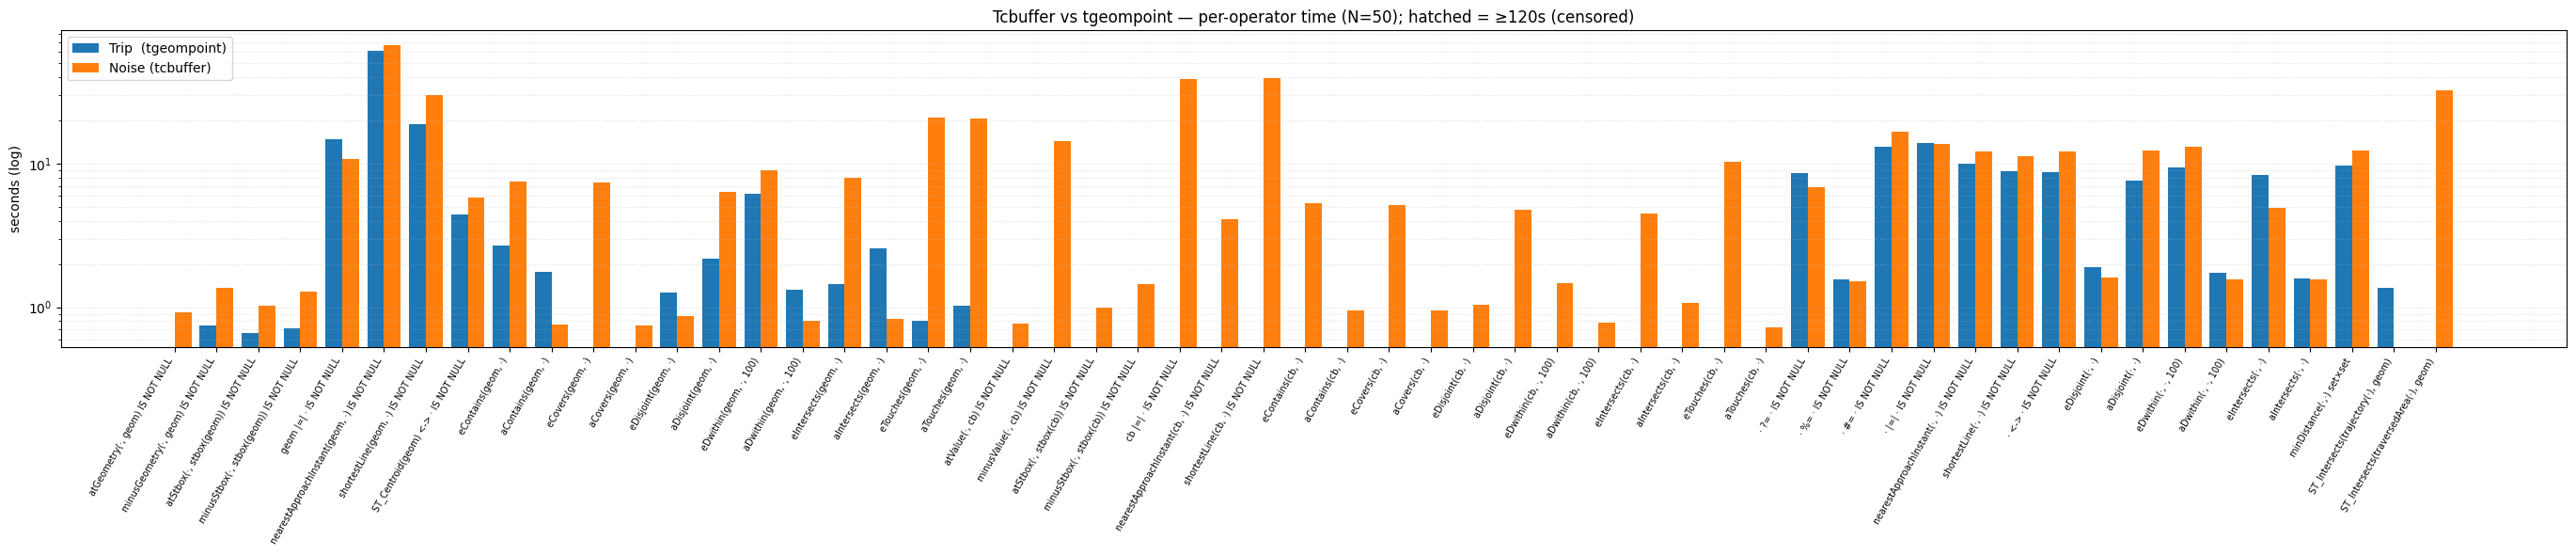

chart written to tcbuffer_vs_tgeompoint.svg


In [10]:
_s = lambda v: v if v is not None else np.nan
ops = list(dict.fromkeys((r[2] for r in results)))   # preserve order
trip  = {r[2]: _s(r[4]) for r in results if r[3] == "Trip"}
noise = {r[2]: _s(r[4]) for r in results if r[3] == "Noise"}
tripC = {r[2]: r[6] for r in results if r[3] == "Trip"}
noiseC= {r[2]: r[6] for r in results if r[3] == "Noise"}
ops = [o for o in ops if o in trip or o in noise]
x = np.arange(len(ops)); w = 0.4
fig, ax = plt.subplots(figsize=(max(10, len(ops)*0.5), 6))
bt = ax.bar(x - w/2, [trip.get(o, np.nan) for o in ops],  w, label="Trip  (tgeompoint)", color="#1f77b4")
bn = ax.bar(x + w/2, [noise.get(o, np.nan) for o in ops], w, label="Noise (tcbuffer)",  color="#ff7f0e")
# hatch the censored (≥ cap) bars so they read as a lower bound, not a measurement
for o, b in zip(ops, bt):
    if tripC.get(o):  b.set_hatch("///"); b.set_edgecolor("k")
for o, b in zip(ops, bn):
    if noiseC.get(o): b.set_hatch("///"); b.set_edgecolor("k")
ax.set_yscale("log"); ax.set_ylabel("seconds (log)")
ax.set_xticks(x); ax.set_xticklabels(ops, rotation=60, ha="right", fontsize=7)
ax.set_title(f"Tcbuffer vs tgeompoint — per-operator time (N={N}); hatched = ≥{STMT_TIMEOUT}s (censored)")
ax.legend(); ax.grid(axis="y", which="both", ls=":", alpha=0.4)
plt.tight_layout(); plt.savefig("tcbuffer_vs_tgeompoint.svg"); plt.show()
print("chart written to tcbuffer_vs_tgeompoint.svg")

## Headline — the noise-exposure gap

How many protected-area reaches does the disk model find that the centerline misses? `eIntersects`
counts a reach when the model ever enters the area; the gap is the noise-only reaches.

In [11]:
reach_trip  = q1("SELECT count(*) FROM VesselTrip100 t1, NaturalAreas100 t2 WHERE eIntersects(Trip,  geom)")
reach_noise = q1("SELECT count(*) FROM VesselTrip100 t1, NaturalAreas100 t2 WHERE eIntersects(Noise, geom)")
print(f"centerline reaches (Trip)  : {reach_trip}")
print(f"noise reaches (Noise)      : {reach_noise}")
print(f"gap (noise-only reaches)   : {reach_noise - reach_trip}")

centerline reaches (Trip)  : 12
noise reaches (Noise)      : 79
gap (noise-only reaches)   : 67


## Reading the matrix

- **Restriction / stbox** (`atGeometry`, `atStbox`, …) are close on both models: bounding-box pruning
  dominates and the disk only widens the box slightly.
- **Distance / nearest approach** (`|=|`, `shortestLine`, `nearestApproachInstant`) is where the disk
  costs most — it sweeps per-segment circles rather than evaluating a point path, and the protected
  areas are high-vertex multipolygons whose vertex-count distribution (mean / median / p95 / max,
  printed in the dataset section) reaches the 10⁴–10⁵ range per area. Each evaluation therefore runs
  against full-resolution geometry; the bounding-box / stbox pruning is what bounds the work, since
  without it every pair would intersect two high-vertex polygons in full.
- **Section C** (vessel × vessel) is the N×N self-join; its absolute cost scales with N², which is why
  N is the knob that sets the run time.

## Known limitations

- `N` bounds the cross join; the printed `N` is the scale of every number here. Raise it for a larger run.
- Operator pairs that are not yet implemented for one model raise rather than approximate; they appear
  as gaps, not as zeros.
- The temporal-output spatial relations are held back by default (`TCBUFFER_RUN_FRONTIER=1` to include
  them). Against the high-vertex multipolygons a single Noise evaluation runs for minutes and does not
  yield to `statement_timeout` cancellation, so they cannot be part of a bounded interactive run.

## Reproduce

```bash
# 1. Build MobilityDB at the ecosystem pin with the cbuffer family enabled
cmake -DMEOS=OFF -DCBUFFER=ON -DPOSTGRESQL_PG_CONFIG=<pg>/bin/pg_config .. && ninja && ninja install

# 2. Load one full day of AIS (centerline + noise tcbuffer + areas)
createdb tcbuffer_bench
psql tcbuffer_bench -c 'CREATE EXTENSION mobilitydb CASCADE'
psql tcbuffer_bench -f tcbuffer_load.sql -c 'SELECT tcbuffer_load(SF:=1)' -c 'ANALYZE'

# 3. Run this notebook (set the scale; full day, N-row cross joins)
PGDATABASE=tcbuffer_bench TCBUFFER_N=100 jupyter nbconvert --execute --to notebook --inplace \
    CrossModel_tcbuffer_timings.ipynb
```

The AIS day is the same `aisdk-2026-02-26.csv` the MobilityAPI tutorials use
(`https://web.ais.dk/aisdata/`).

## Export the static catalog

Write the sibling `.md` catalog from the same results, so the markdown reference never drifts from
the executed numbers.

In [12]:
lines = [f"# Tcbuffer vs tgeompoint — timing catalog (N={N})", "",
         f"One full day of Danish AIS · MobilityDB `{q1('SELECT mobilitydb_version()')}` · generated from the notebook.", "",
         f"**Headline** — noise-only protected-area reaches: **{reach_noise - reach_trip}** "
         f"(noise {reach_noise} vs centerline {reach_trip}).", "",
         "| Section | Operator | Trip (s) | Noise (s) | Noise/Trip |", "|---|---|---:|---:|---:|"]
for _, row in pivot.iterrows():
    t = row.get("Trip"); n = row.get("Noise"); rr = row.get("ratio", float("nan"))
    lines.append(f"| {row['section']} | `{row['operator']}` | "
                 f"{'' if pd.isna(t) else f'{t:.3f}'} | {'' if pd.isna(n) else f'{n:.3f}'} | "
                 f"{'' if pd.isna(rr) else f'{rr:.1f}×'} |")
lines += ["", f"_{ncens} operator(s) censored at the {STMT_TIMEOUT}s cap against full-resolution multipolygons._",
          "", "![Trip vs Noise](tcbuffer_vs_tgeompoint.svg)"]
open("tcbuffer_timings.md", "w").write("\n".join(lines) + "\n")
print("wrote tcbuffer_timings.md + tcbuffer_vs_tgeompoint.svg")

wrote tcbuffer_timings.md + tcbuffer_vs_tgeompoint.svg


## Summary

On one full day of AIS, modelling vessels as moving **disks** (`tcbuffer`) rather than moving
**points** (`tgeompoint`) widens what the queries can express — noise-aware reaches, footprint
coverage, encounter distance with vessel extent — at a cost that is negligible for bounding-box
restriction and largest for the swept-area distance operators. The grouped chart and the headline gap
quantify that trade on the same engine, with natural SQL and exact operators.